# Custom Theme

1. [Custom Theme](#custom_theme)

2. [Theme Elements](#theme_elements)

    2.1. [Lines](#theme_elements-lines)

    2.2. [Rectangles](#theme_elements-rectangles)

    2.3. [Texts](#theme_elements-texts)

    2.4. [Geometries](#theme_elements-geometries)

    2.5. [Blank](#theme_elements-blank)

3. [Theme Parameters](#theme_parameters)

    3.1. [All Elements of Given Type](#theme_parameters-given_type)

    3.2. [Axes](#theme_parameters-axes)

    3.3. [Legend](#theme_parameters-legend)

    3.4. [Panel](#theme_parameters-panel)

    3.5. [Plot](#theme_parameters-plot)

    3.6. [Facetting](#theme_parameters-facetting)

    3.7. [Tooltips](#theme_parameters-tooltips)

    3.8. [Annotations](#theme_parameters-annotations)

    3.9. [Other](#theme_parameters-other)

4. [Extra](#extra)

    4.1. [Plot Size](#extra-plot_size)

    4.2. [Labels](#extra-labels)

    4.3. [Mixing](#extra-mixing)

5. [Custom Theme for Different Plot Types](#plot_types)

    5.1. [Correlation Plot](#plot_types-corr)

    5.2. [Image Plot](#plot_types-image)

    5.3. [Interactive Map Plot](#plot_types-livemap)

    5.4. [Polar Bar Plot](#plot_types-polar)

    5.5. [Marginal Plot](#plot_types-marginal)

    5.6. [Plot Group](#plot_types-gggrid)

6. [Set up Global Theme](#global_theme)

In [1]:
from lets_plot import *

In [2]:
LetsPlot.setup_html()

In [3]:
def get_data():
    import pandas as pd
    df = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/master/data/mpg.csv")
    return df.drop(columns=["Unnamed: 0"])

In [4]:
df = get_data()
print(df.shape)
df.head()

(234, 11)


,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [5]:
def bar_title(subtitle):
    return ggtitle("Bar plot", subtitle)

def bar_plot(*, color=True, facet=False, sampling=None):
    color_col = "fl" if color else None
    plot = ggplot(df) + \
        geom_bar(aes("fl", color=color_col, fill=color_col), \
                 sampling=sampling, \
                 tooltips=layer_tooltips().title("Fuel type: @fl").line("count|@..count.."), \
                 labels=layer_labels().line("@..count.."))
    if facet:
        plot += facet_grid(x="year")
    return plot

<a id="custom_theme"></a>
## 1. Custom Theme

In [6]:
def theme_orange():
    yellow_light = "#ffffcc"
    orange_light = "#fff5eb"
    orange_normal = "#f16913"
    orange_dark = "#7f2704"
    return theme_none() + theme(
        line=element_line(color=orange_normal, size=2),
        rect=element_rect(color=orange_normal, fill=orange_light, size=2),
        text=element_text(color=orange_dark),
        geom=element_geom(pen=orange_dark),
        axis_ontop=True,
        axis_ticks=element_line(color=orange_normal, size=2),
        axis_ticks_length=7,
        legend_background=element_rect(size=2, fill=orange_light),
        legend_position='bottom',
        panel_grid_major=element_line(color=orange_normal, size=.5),
        panel_grid_minor='blank',
        plot_background=element_rect(fill=yellow_light, size=2),
        plot_title=element_text(size=20, face='bold'),
        axis_tooltip=element_rect(color=orange_dark)
    )

In [7]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + theme_orange() + bar_title("Custom theme"),
])

<a id="theme_elements"></a>
## 2. Theme Elements

<a id="theme_elements-lines"></a>
### 2.1. Lines

In [8]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(panel_grid=element_line(color="red", size=2, linetype='longdash')) + \
        bar_title("Custom element_line() for panel grid"),
])

<a id="theme_elements-rectangles"></a>
### 2.2. Rectangles

In [9]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(panel_background=element_rect(color="black", fill="lightgray", size=2, linetype='longdash')) + \
        bar_title("Custom element_rect() for panel background"),
])

<a id="theme_elements-texts"></a>
### 2.3. Texts

In [10]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(axis_text_y=element_text(color="red", family="Times", \
                                       face='bold', size=20, angle=15, \
                                       margin=[0, 5])) + \
        bar_title("Custom element_text() for y-axis text"),
])

In [11]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(plot_title=element_text(size=20, hjust=.5, margin=[20, 0, 10])) + \
        bar_title("Custom element_text() for plot_title"),
])

<a id="theme_elements-geometries"></a>
### 2.4. Geometries

In [12]:
gggrid([
    bar_plot(color=False) + bar_title("Default"),
    bar_plot(color=False) + \
        theme(geom=element_geom(brush="yellow", paper="red")) + \
        bar_title("Custom element_geom() for geom"),
])

<a id="theme_elements-blank"></a>
### 2.5. Blank

In [13]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(panel_grid=element_blank()) + \
        bar_title("panel_grid=element_blank()"),
    bar_plot() + \
        theme(panel_grid='blank') + \
        bar_title("panel_grid='blank'"),
    bar_plot() + \
        theme(panel_grid=element_line(blank=True)) + \
        bar_title("panel_grid=element_line(blank=True)"),
], ncol=2)

<a id="theme_parameters"></a>
## 3. Theme Parameters

<a id="theme_parameters-given_type"></a>
### 3.1. All Elements of Given Type

#### `line`

In [14]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(line=element_line(linetype='longdash')) + \
        bar_title("Custom line"),
])

#### `rect`

In [15]:
# The default theme has defaults for most rectangular elements,
# so we need to switch to another predefined theme to see the effect

gggrid([
    bar_plot() + theme_light() + bar_title("Default"),
    bar_plot() + theme_light() + \
        theme(rect=element_rect(linetype='longdash')) + \
        bar_title("Custom rect"),
])

#### `text` and `title`

In [16]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(text=element_text(color="red")) + \
        bar_title("Custom text"),
    bar_plot() + \
        theme(title=element_text(color="blue")) + \
        bar_title("Custom title"),
    bar_plot() + \
        theme(text=element_text(color="red"), title=element_text(color="blue")) + \
        bar_title("Custom text and title"),
], ncol=2)

<a id="theme_parameters-axes"></a>
### 3.2. Axes

#### `axis`

In [17]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(axis=element_line(color="red", size=3)) + \
        bar_title("Custom axis"),
])

#### `axis_ontop`

In [18]:
gggrid([
    bar_plot() + \
        theme(axis=element_text(size=4)) + \
        bar_title("axis_ontop=True (default)"),
    bar_plot() + \
        theme(axis=element_text(size=4), axis_ontop=False) + \
        bar_title("axis_ontop=False"),
])

#### `axis_title`

In [19]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(axis_title=element_text(color="red")) + \
        bar_title("Custom axis_title"),
])

#### `axis_text`

In [20]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(axis_text=element_text(color="red")) + \
        bar_title("Custom axis_text"),
])

#### `axis_ticks` and `axis_ticks_length`

In [21]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(axis_ticks=element_line(color="red", size=3)) + \
        bar_title("Custom axis_ticks"),
    bar_plot() + \
        theme(axis_ticks_length=10) + \
        bar_title("Custom axis_ticks_length"),
])

#### `axis_line`

In [22]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(axis_line=element_line(color="red", size=3)) + \
        bar_title("Custom axis_line"),
    bar_plot() + \
        theme(axis=element_line(color="red", size=3), \
              axis_line=element_line(color="blue", size=3)) + \
        bar_title("axis vs. axis_line"),
])

<a id="theme_parameters-legend"></a>
### 3.3. Legend

#### `legend_background`

In [23]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(legend_background=element_rect(fill="lightgray")) + \
        bar_title("Custom legend_background"),
])

#### `legend_text`

In [24]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(legend_text=element_text(color="red")) + \
        bar_title("Custom legend_text"),
])

#### `legend_title`

In [25]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(legend_title=element_text(color="red")) + \
        bar_title("Custom legend_title"),
])

#### `legend_position` and `legend_justification`

In [26]:
# Let's set a custom theme to see what happens when parameters are specified

gggrid([
    bar_plot() + \
        theme_bw() + \
        bar_title("Default"),
    bar_plot() + \
        theme_bw() + theme(legend_position='top') + \
        bar_title("legend_position='top'"),
    bar_plot() + \
        theme_bw() + theme(legend_position=[1, 1]) + \
        bar_title("legend_position=[1, 1]"),
    bar_plot() + \
        theme_bw() + theme(legend_position=[1, 1], legend_justification=[1, 1]) + \
        bar_title("legend_position=[1, 1],\nlegend_justification=[1, 1]"),
], ncol=2)

#### `legend_direction`

In [27]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(legend_direction='horizontal') + \
        bar_title("Custom legend_direction"),
])

<a id="theme_parameters-panel"></a>
### 3.4. Panel

#### `panel_background` and `panel_border`

In [28]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(panel_background=element_rect(color="black", fill="lightgray")) + \
        bar_title("Custom panel_background"),
    bar_plot() + \
        theme(panel_border=element_rect(size=3, color="red")) + \
        bar_title("Custom panel_border"),
    bar_plot() + \
        theme(panel_background=element_rect(color="black", fill="lightgray"), \
              panel_border=element_rect(size=3, color="red")) + \
        bar_title("Custom panel_background and panel_border"),
], ncol=2)

#### `panel_grid`

In [29]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(panel_grid=element_line(linetype='longdash')) + \
        bar_title("Custom panel_grid"),
])

#### `panel_border_ontop`

In [30]:
gggrid([
    bar_plot() + \
        theme(panel_border=element_rect(size=5)) + \
        bar_title("panel_border_ontop=True (default)"),
    bar_plot() + \
        theme(panel_border=element_rect(size=5), panel_border_ontop=False) + \
        bar_title("panel_border_ontop=False"),
])

#### `panel_grid_ontop`

In [31]:
gggrid([
    bar_plot() + \
        bar_title("panel_grid_ontop=False (default)"),
    bar_plot() + \
        theme(panel_grid_ontop=True) + \
        bar_title("panel_grid_ontop=True"),
])

#### `panel_inset`

In [32]:
# Let's set a custom theme to see what happens when panel_inset parameter is specified

gggrid([
    bar_plot() + theme_bw() + bar_title("Default"),
    bar_plot() + theme_bw() + \
        theme(panel_inset=50) + \
        bar_title("panel_inset=50"),
    bar_plot() + theme_bw() + \
        theme(panel_inset=[50]) + \
        bar_title("panel_inset=[50]"),
    bar_plot() + theme_bw() + \
        theme(panel_inset=[50, 25]) + \
        bar_title("panel_inset=[50, 25]"),
    bar_plot() + theme_bw() + \
        theme(panel_inset=[100, 25, 50]) + \
        bar_title("panel_inset=[100, 25, 50]"),
    bar_plot() + theme_bw() + \
        theme(panel_inset=[100, 0, 50, 25]) + \
        bar_title("panel_inset=[100, 0, 50, 25]"),
], ncol=3)

<a id="theme_parameters-plot"></a>
### 3.5. Plot

#### `plot_background`

In [33]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(plot_background=element_rect(fill="lightgray")) + \
        bar_title("Custom plot_background"),
    bar_plot() + \
        theme(plot_background=element_rect(fill="lightgray"), \
              panel_background=element_rect(fill="white")) + \
        bar_title("plot_background vs. panel_background"),
])

#### `plot_title`, `plot_subtitle`, `plot_caption`

In [34]:
gggrid([
    bar_plot() + \
        labs(title="Default title", subtitle="Default subtitle", caption="Default caption"),
    bar_plot() + \
        theme(plot_title=element_text(color="red")) + \
        labs(title="Custom plot_title", subtitle="Default subtitle", caption="Default caption"),
    bar_plot() + \
        theme(plot_subtitle=element_text(color="red")) + \
        labs(title="Default title", subtitle="Custom plot_subtitle", caption="Default caption"),
    bar_plot() + \
        theme(plot_caption=element_text(color="red")) + \
        labs(title="Default title", subtitle="Default subtitle", caption="Custom plot_caption"),
], ncol=2)

#### `plot_margin`

In [35]:
# Let's set a custom theme to see what happens when plot_margin parameter is specified

gggrid([
    bar_plot() + theme_bw() + bar_title("Default"),
    bar_plot() + theme_bw() + \
        theme(plot_margin=50) + \
        bar_title("plot_margin=50"),
    bar_plot() + theme_bw() + \
        theme(plot_margin=[50]) + \
        bar_title("plot_margin=[50]"),
    bar_plot() + theme_bw() + \
        theme(plot_margin=[50, 25]) + \
        bar_title("plot_margin=[50, 25]"),
    bar_plot() + theme_bw() + \
        theme(plot_margin=[100, 25, 50]) + \
        bar_title("plot_margin=[100, 25, 50]"),
    bar_plot() + theme_bw() + \
        theme(plot_margin=[100, 0, 50, 25]) + \
        bar_title("plot_margin=[100, 0, 50, 25]"),
], ncol=3)

#### `plot_inset`

In [36]:
# Let's set a custom theme to see what happens when plot_inset parameter is specified

gggrid([
    bar_plot() + theme_bw() + bar_title("Default"),
    bar_plot() + theme_bw() + \
        theme(plot_inset=50) + \
        bar_title("plot_inset=50"),
    bar_plot() + theme_bw() + \
        theme(plot_inset=[50]) + \
        bar_title("plot_inset=[50]"),
    bar_plot() + theme_bw() + \
        theme(plot_inset=[50, 25]) + \
        bar_title("plot_inset=[50, 25]"),
    bar_plot() + theme_bw() + \
        theme(plot_inset=[100, 25, 50]) + \
        bar_title("plot_inset=[100, 25, 50]"),
    bar_plot() + theme_bw() + \
        theme(plot_inset=[100, 0, 50, 25]) + \
        bar_title("plot_inset=[100, 0, 50, 25]"),
], ncol=3)

#### `plot_margin` vs. `plot_inset` vs. `panel_inset`

In [37]:
# Let's set a custom theme to see what happens when parameters are specified

gggrid([
    bar_plot() + theme_bw() + bar_title("Default"),
    bar_plot() + theme_bw() + \
        theme(plot_margin=50) + \
        bar_title("plot_margin=50"),
    bar_plot() + theme_bw() + \
        theme(plot_inset=50) + \
        bar_title("plot_inset=50"),
    bar_plot() + theme_bw() + \
        theme(panel_inset=50) + \
        bar_title("panel_inset=50"),
], ncol=2)

#### `plot_message`

In [38]:
gggrid([
    bar_plot(sampling=sampling_pick(3)) + bar_title("Default"),
    bar_plot(sampling=sampling_pick(3)) + \
        theme(plot_message='blank') + \
        bar_title("plot_message='blank'"),
])

<a id="theme_parameters-facetting"></a>
### 3.6. Facetting

#### `strip_background`

In [39]:
gggrid([
    bar_plot(facet=True) + bar_title("Default"),
    bar_plot(facet=True) + \
        theme(strip_background=element_rect()) + \
        bar_title("Custom strip_background"),
])

#### `strip_text`

In [40]:
gggrid([
    bar_plot(facet=True) + bar_title("Default"),
    bar_plot(facet=True) + \
        theme(strip_text=element_text(color="red")) + \
        bar_title("Custom strip_text"),
])

<a id="theme_parameters-tooltips"></a>
### 3.7. Tooltips

#### `tooltip`

In [41]:
# Hover over the plot to see tooltips

gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(tooltip=element_rect(color="red", fill="yellow")) + \
        bar_title("Custom tooltip"),
])

#### `tooltip_text` and `tooltip_title_text`

In [42]:
# Hover over the plot to see tooltips

gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(tooltip_text=element_text(color="red")) + \
        bar_title("Custom tooltip_text"),
    bar_plot() + \
        theme(tooltip_title_text=element_text(color="blue")) + \
        bar_title("Custom tooltip_title_text"),
    bar_plot() + \
        theme(tooltip_text=element_text(color="red"), \
              tooltip_title_text=element_text(color="blue")) + \
        bar_title("Custom tooltip_text and tooltip_title_text"),
], ncol=2)

#### `axis_tooltip` and `axis_tooltip_text`

In [43]:
# Hover over the plot to see tooltips

gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(axis_tooltip=element_rect(color="red", fill="blue")) + \
        bar_title("Custom axis_tooltip"),
    bar_plot() + \
        theme(axis_tooltip_text=element_text(color="yellow")) + \
        bar_title("Custom axis_tooltip_text"),
    bar_plot() + \
        theme(axis_tooltip=element_rect(color="red", fill="blue"), \
              axis_tooltip_text=element_text(color="yellow")) + \
        bar_title("Custom axis_tooltip and axis_tooltip_text"),
], ncol=2)

<a id="theme_parameters-annotations"></a>
### 3.8. Annotations

#### `label_text`

In [44]:
gggrid([
    bar_plot() + bar_title("Default"),
    bar_plot() + \
        theme(label_text=element_text(size=20, face='bold')) + \
        bar_title("Custom label_text"),
])

<a id="theme_parameters-other"></a>
### 3.9. Other

#### `exponent_format`

In [45]:
def exp_bar_plot():
    import numpy as np
    exp = 10**(-4)
    groups = list("abcde")
    np.random.seed(42)
    data = {
        'x': groups,
        'y': exp * np.random.uniform(size=len(groups)),
    }
    return ggplot(data, aes('x', 'y')) + geom_bar(stat='identity')

In [46]:
gggrid([
    exp_bar_plot() + bar_title("exponent_format='e' (default)"),
    exp_bar_plot() + \
        theme(exponent_format='pow') + \
        bar_title("exponent_format='pow'"),
])

<a id="extra"></a>
## 4. Extra

<a id="extra-plot_size"></a>
### 4.1. Plot Size

#### Default

In [47]:
bar_plot()

#### Custom Size

In [48]:
bar_plot() + ggsize(1000, 400)

#### `GGBunch`

In [49]:
bunch = GGBunch()
bunch.add_plot(bar_plot(), 0, 0, 1000, 400)
bunch.add_plot(bar_plot(), 600, 0, 400, 300)
bunch.show()

#### `gggrid()`

In [50]:
gggrid([
    bar_plot(),
    bar_plot(),
]) + ggsize(1000, 200)

<a id="extra-labels"></a>
### 4.2. Labels

#### Set Title

In [51]:
gggrid([
    bar_plot() + ggtitle("Using ggtitle()"),
    bar_plot() + labs(title="Using labs()"),
])

#### Set Subtitle

In [52]:
gggrid([
    bar_plot() + ggtitle("Bar plot", subtitle="Using ggtitle()"),
    bar_plot() + labs("Bar plot", subtitle="Using labs()"),
])

#### Set Caption

In [53]:
bar_plot() + labs("Bar plot", caption="Only with labs()")

#### Set Axis Title

In [54]:
bar_plot() + xlab("Fuel type\n(fl)") + ylab("Number of records\n(for given fuel type)")

#### Set Legend Title

In [55]:
bar_plot() + labs(color="Fuel type\n(fl)", fill="Fuel type\n(fl)")

<a id="extra-mixing"></a>
### 4.3. Mixing

In [56]:
gggrid([
    bar_plot() + \
        theme_void() + theme(text=element_text(color="red")) + \
        bar_title("Mixing predefined theme with custom"),
    bar_plot() + \
        theme(text=element_text(color="red")) + theme(panel_grid=element_line(color="blue")) + \
        bar_title("Mixing custom themes with parameters of different type"),
    bar_plot() + \
        theme(plot_title=element_text(color="red")) + theme(plot_subtitle=element_text(color="blue")) + \
        bar_title("Mixing custom themes with parameters of same type"),
    bar_plot() + \
        theme(text=element_text(color="blue")) + theme(plot_title=element_text(color="red")) + \
        bar_title("Mixing custom themes with inherited parameters"),
    bar_plot() + \
        theme(plot_title=element_text(color="red")) + theme(plot_title=element_text(size=24)) + \
        bar_title("Mixing custom themes with same parameter\nbut different options"),
    bar_plot() + \
        theme(plot_title=element_text(color="red")) + theme(plot_title=element_text(color="blue")) + \
        bar_title("Mixing custom themes with same parameter and option"),
], ncol=2)

<a id="plot_types"></a>
## 5. Custom Theme for Different Plot Types

<a id="plot_types-corr"></a>
### 5.1. Correlation Plot

In [57]:
def corr_plot():
    from lets_plot.bistro.corr import corr_plot
    return corr_plot(df, show_legend=False).tiles().build()

gggrid([
    corr_plot() + ggtitle("Correlation plot", "Default"),
    corr_plot() + theme_orange() + ggtitle("Correlation plot", "Custom theme"),
])

<a id="plot_types-image"></a>
### 5.2. Image Plot


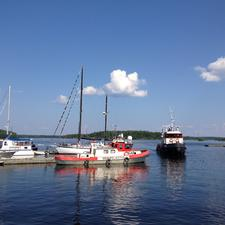
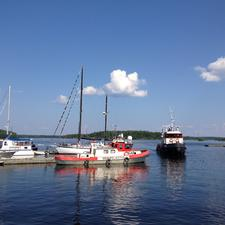

In [58]:
def image_plot():
    import requests
    from io import BytesIO
    from PIL import Image
    import numpy as np
    response = requests.get("https://github.com/JetBrains/lets-plot-docs/raw/master/source/examples/cookbook/images/fisher_boat.png")
    image = Image.open(BytesIO(response.content))
    return ggplot() + geom_imshow(np.asarray(image))

gggrid([
    image_plot() + ggtitle("Image plot", "Default"),
    image_plot() + theme_orange() + ggtitle("Image plot", "Custom theme"),
])

<a id="plot_types-livemap"></a>
### 5.3. Interactive Map Plot

In [59]:
def interactive_map_plot():
    return ggplot() + geom_livemap(zoom=10) + geom_point(y=40.7127, x=-74.0059, color="red")

gggrid([
    interactive_map_plot() + ggtitle("Interactive map plot", "Default"),
    interactive_map_plot() + theme_orange() + ggtitle("Interactive map plot", "Custom theme"),
])

<a id="plot_types-polar"></a>
### 5.4. Polar Bar Plot

In [60]:
def polar_bar_plot():
    return bar_plot() + scale_y_continuous(trans='symlog') + coord_polar(ylim=[-.5, None])

gggrid([
    polar_bar_plot() + ggtitle("Polar bar plot", "Default"),
    polar_bar_plot() + theme_orange() + ggtitle("Polar bar plot", "Custom theme"),
])

<a id="plot_types-marginal"></a>
### 5.5. Marginal Plot

In [61]:
def marginal_plot():
    return ggplot(df, aes("cty", "hwy")) + geom_point() + ggmarginal("tr", layer=geom_density())

gggrid([
    marginal_plot() + ggtitle("Marginal plot", "Default"),
    marginal_plot() + theme_orange() + ggtitle("Marginal plot", "Custom theme"),
])

<a id="plot_types-gggrid"></a>
### 5.6. Plot Group

In [62]:
def plot_group(subtitle):
    return gggrid([bar_plot() + ggtitle("Plot group", subtitle), bar_plot()], ncol=1)

gggrid([
    plot_group("Default"),
    plot_group("Custom theme") + theme_orange()
])

<a id="global_theme"></a>
## 6. Set up Global Theme

In [63]:
LetsPlot.set_theme(theme_bw() + flavor_darcula() + theme(panel_grid=element_line(linetype='longdash')))

In [64]:
bar_plot()